In [2]:
from astropy.io import fits
from astropy.table import Table

# Open the file
with fits.open('../hlsp_jades_jwst_nircam_goods-n_photometry_v5.0_catalog.fits') as hdul:
    # Target the PHOTOZ extension columns
    photoz_columns = hdul['PHOTOZ'].columns

    # Print a clean layout of all 34 columns, their formats, and their units
    # photoz_columns.info()

    data_table = Table.read(hdul['PHOTOZ'], format='fits')

    flag_columns = hdul['FLAG'].columns
    ra_dec = Table.read(hdul['FLAG'], format='fits')[['RA', 'DEC']]

    data_table['RA'] = ra_dec['RA']
    data_table['DEC'] = ra_dec['DEC']
    print(data_table.colnames)

['ID', 'z_spec', 'z_a', 'z_ml', 'chi_a', 'l68', 'u68', 'l95', 'u95', 'l99', 'u99', 'nfilt', 'z_peak', 'chi_peak', 'z025', 'z160', 'z500', 'z840', 'z975', 'Prob_gt_5', 'Prob_gt_6', 'Prob_gt_7', 'Prob_gt_8', 'Prob_gt_9', 'chisq_z_lt_7', 'z_chisq_z_lt_7', 'chisq_z_lt_6', 'z_chisq_z_lt_6', 'chisq_z_lt_5', 'z_chisq_z_lt_5', 'chisq_z_lt_4', 'z_chisq_z_lt_4', 'z_bins', 'Prob_z_bins', 'RA', 'DEC']


In [3]:
target_id = 1000019

# Find the row corresponding to the target ID
target_row = data_table[data_table['ID'] == target_id]
print(f'Photometric redshift for target ID {target_id}: {target_row["z_a"][0]}')
target_row

Photometric redshift for target ID 1000019: 4.019999980926514


ID,z_spec,z_a,z_ml,chi_a,l68,u68,l95,u95,l99,u99,nfilt,z_peak,chi_peak,z025,z160,z500,z840,z975,Prob_gt_5,Prob_gt_6,Prob_gt_7,Prob_gt_8,Prob_gt_9,chisq_z_lt_7,z_chisq_z_lt_7,chisq_z_lt_6,z_chisq_z_lt_6,chisq_z_lt_5,z_chisq_z_lt_5,chisq_z_lt_4,z_chisq_z_lt_4,z_bins,Prob_z_bins,RA,DEC
,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,deg,deg
int64,float64,float32,float32,float32,float64,float64,float64,float64,float64,float64,int64,float64,float64,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64[22],float64[22],float64,float64
1000019,-9999.0,4.02,4.003049,13.769619,3.92624054546614,4.192574972283892,3.8236913929009546,4.30599812609268,3.7003625662762984,4.3982519939143225,16,4.019999980926514,13.76961898803711,3.8271248,3.926201,4.0514293,4.190534,4.300064,2.555471893123107e-12,3.7453274590866806e-27,4.203895392974451e-45,0.0,0.0,13.76961898803711,4.019999980926514,13.76961898803711,4.019999980926514,13.76961898803711,4.019999980926514,13.795021057128906,3.990000009536743,0.35 .. 21.0,4.443633376613168e-11 .. 0.0,189.12386,62.212776


In [25]:
target_ra = 189.0170023
target_dec = 62.2415827

distance = ((data_table['RA'] - target_ra)**2 + (data_table['DEC'] - target_dec)**2)**0.5 * 3600 # Convert to arcseconds
closest_index = distance.argmin()
closest_row = data_table[closest_index]
print(f'Closest object to target location is ID {closest_row["ID"]} with photometric redshift {closest_row["z_a"]}')

dist_tolerance = 20 # in ARCSECONDS
redshift_tolerance = 1
close_distances = data_table[distance < dist_tolerance]
close_redshifts = data_table[abs(data_table['z_a'] - closest_row['z_a']) < redshift_tolerance]
print(f'Objects within {dist_tolerance} arcseconds: {len(close_distances)}')
print(f'Objects within redshift difference of {redshift_tolerance} from the closest object: {len(close_redshifts)}')
close_objects = data_table[(distance < dist_tolerance) & (abs(data_table['z_a'] - closest_row['z_a']) < redshift_tolerance)]
print(f'Objects within {dist_tolerance} arcseconds and redshift difference of {redshift_tolerance} from the closest object:')
print(close_objects[['ID', 'RA', 'DEC', 'z_a']])

# Print five closest objects within the redshift tolerance
closest_within_redshift = data_table[abs(data_table['z_a'] - closest_row['z_a']) < redshift_tolerance]
closest_within_redshift_distance = ((closest_within_redshift['RA'] - target_ra)**2 + (closest_within_redshift['DEC'] - target_dec)**2)**0.5 * 3600
closest_within_redshift['distance'] = closest_within_redshift_distance
closest_within_redshift.sort('distance')
print(closest_within_redshift[['ID', 'RA', 'DEC', 'z_a', 'distance']][:5])

Closest object to target location is ID 1087030 with photometric redshift 9.510000228881836
Objects within 20 arcseconds: 85
Objects within redshift difference of 1 from the closest object: 1786
Objects within 20 arcseconds and redshift difference of 1 from the closest object:
   ID      RA      DEC    z_a 
          deg      deg        
------- ------- --------- ----
1087030 189.017 62.241585 9.51
   ID       RA       DEC    z_a        distance      
           deg       deg                 deg         
------- --------- --------- ---- --------------------
1087030   189.017 62.241585 9.51 0.011709688306677528
3301335  189.0284 62.241177 9.32    41.05770530399649
2019196 189.01508   62.2587 8.65     62.0096417315422
1259498  189.0389 62.228786 9.25    91.30559543916172
1182189 189.04318 62.235115 9.57     97.0734590025544


In [26]:
print('Total number of objects within redshift tolerance:', len(close_redshifts))

Total number of objects within redshift tolerance: 1786


In [23]:
import numpy as np
np.sum(distance < dist_tolerance)

85

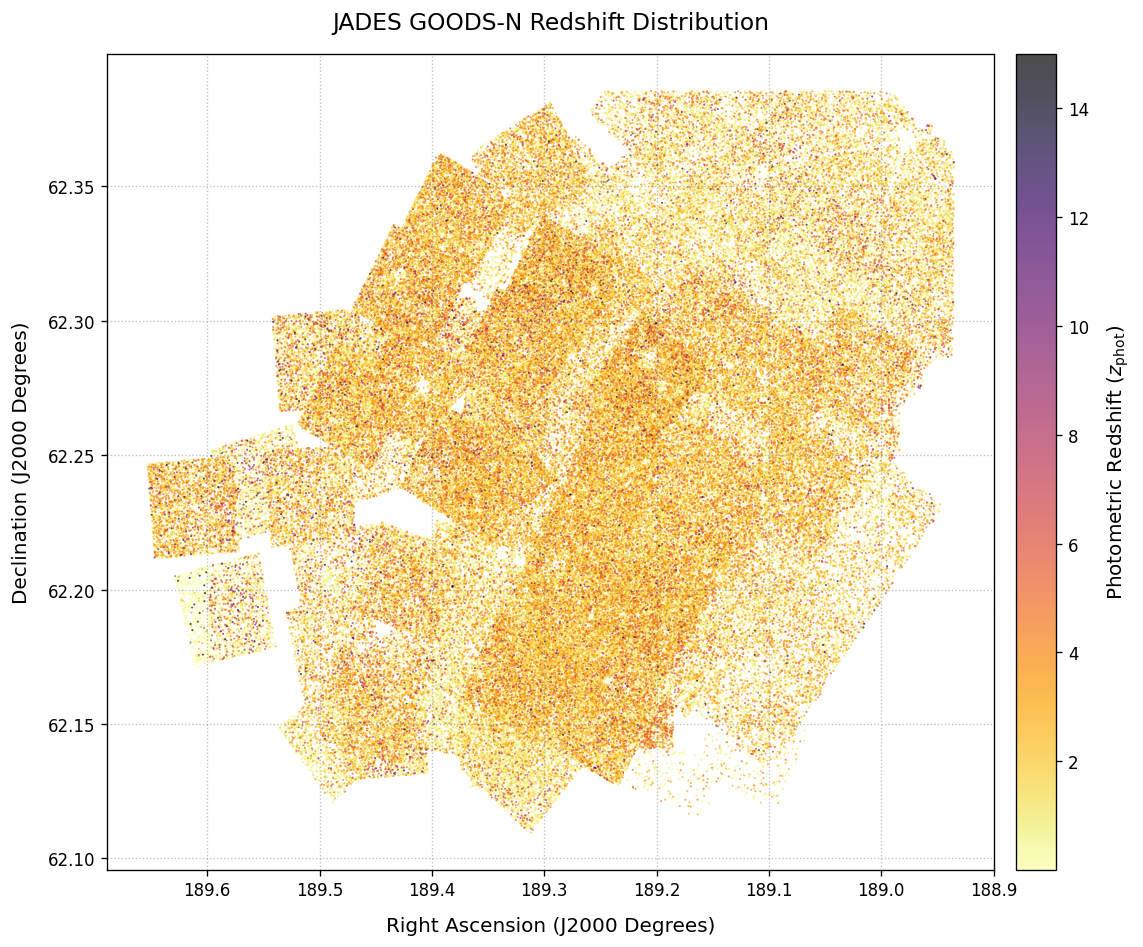

In [34]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- 1. Clean the Data ---
# Assuming 'df' is your merged DataFrame containing 'RA', 'DEC', and 'z_phot'

# Filter out common null/placeholder values (e.g., negative fills like -99)
# and isolate sources with a realistic redshift range
df = data_table[['ID', 'RA', 'DEC', 'z_a']].to_pandas()  # Convert to pandas DataFrame for easier manipulation
valid_data = df[(df['z_a'] >= 0) & (df['z_a'] < 15)].dropna(subset=['RA', 'DEC', 'z_a'])

# Pull out arrays for plotting
ra = valid_data['RA']
dec = valid_data['DEC']
z = valid_data['z_a']

# --- 2. Set Up the Plot ---
plt.figure(figsize=(10, 8), dpi=120)

# We use the 'inferno' or 'viridis' colormap, which are perceptually uniform 
# and make it easy to separate low vs. high redshift features.
sc = plt.scatter(
    ra, 
    dec, 
    c=z, 
    cmap='inferno_r', 
    s=1.5,          # Small marker size so crowded regions don't completely blur together
    alpha=0.7,      # Slight transparency helps see overdensities/overlapping points
    edgecolors='none'
)

# --- 3. Format and Invert the Coordinates ---
# CRITICAL FOR ASTRONOMY: RA increases to the left on the sky!
plt.gca().invert_xaxis()

# Add standard astronomical labeling
plt.xlabel("Right Ascension (J2000 Degrees)", fontsize=12, labelpad=10)
plt.ylabel("Declination (J2000 Degrees)", fontsize=12, labelpad=10)
plt.title("JADES GOODS-N Redshift Distribution", fontsize=14, pad=15)

# --- 4. Add the Colorbar ---
cbar = plt.colorbar(sc, pad=0.02)
cbar.set_label("Photometric Redshift ($z_{\mathrm{phot}}$)", fontsize=12, labelpad=10)
cbar.ax.tick_params(labelsize=10)

# --- 5. Clean up Layout and Show ---
plt.tight_layout()
plt.grid(True, linestyle=':', alpha=0.5, color='gray')
plt.show()

In [ ]:
import requests

url = "https://archive.stsci.edu/hlsps/jades/dr3/goods-n/catalogs/" \
      "hlsp_jades_jwst_nircam_goods-n_photometry_v1.0_catalog.fits"

headers = {"Range": "bytes=0-500000"}

r = requests.get(url, headers=headers)
data = r.content

with open("partial.fits", "wb") as f:
    f.write(data)

In [33]:
from astropy.io import fits

hdul = fits.open("partial.fits")
hdul.info()

Filename: partial.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      13   ()      
  1  FILTERS       1 BinTableHDU     33   30R x 12C   [6A, E, E, E, E, E, E, E, E, E, E, E]   
  2  FLAG          1 BinTableHDU    203   85709R x 96C   [J, D, D, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, J, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, I, E, E]   


In [42]:
from astropy.io import fits
from astropy.table import Table
import pandas as pd

url = "https://archive.stsci.edu/hlsps/jades/dr3/goods-n/catalogs/" \
      "hlsp_jades_jwst_nircam_goods-n_photometry_v1.0_catalog.fits"

print("Streaming remote FITS catalog mapping via fsspec...")

try:
    # Passing the verified URL block
    # 'anon': True keeps the connection open without looking for local AWS/MAST login keys
    with fits.open(url, use_fsspec=True, fsspec_kwargs={"anon": True}) as hdul:
        
        print(f"Connected! Internal Extensions found: {[hdu.name for hdu in hdul]}")
        
        print("\nExtracting ONLY Extension 9 (PHOTOZ)...")
        photoz_table = Table(hdul['PHOTOZ'].data)
        
    # Convert to pandas for exploration
    df = photoz_table.to_pandas()
    print(f"\nSuccess! Loaded {len(df)} rows of GOODS-N redshift data.")
    print(df.head())

except FileNotFoundError as e:
    print(f"File not found error: {e}")
    print("If this persists, your environment's fsspec HTTP driver is missing network access.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Streaming remote FITS catalog mapping via fsspec...
File not found error: https://archive.stsci.edu/hlsps/jades/dr3/goods-n/catalogs/hlsp_jades_jwst_nircam_goods-n_photometry_v1.0_catalog.fits
If this persists, your environment's fsspec HTTP driver is missing network access.


In [ ]:
from astroquery.mast import Observations
from astropy.table import Table
import os

# Enter your token when prompted or pass it directly to the login function
# Observations.login(token="YOUR_MAST_API_TOKEN")
Observations.login() 

filename = "hlsp_jades_jwst_nircam_goods-n_photometry_v1.0_catalog.fits"
data_uri = f"mast:HLSP/jades/{filename}"

print(f"Requesting file via authenticated MAST Data URI...")
try:
    local_path = Observations.download_file(data_uri, local_path=f"./{filename}")
    print(f"Download complete! File saved to: {local_path}")
    
    # Read extension 9 directly from local copy
    photoz_table = Table.read(local_path, hdu=9)
    print(f"Successfully loaded {len(photoz_table)} rows.")
except Exception as e:
    print(f"Astroquery download failed: {e}")

INFO: If you do not have an API token already, visit the following link to create one: https://auth.mast.stsci.edu/token?suggested_name=Astroquery&suggested_scope=mast:exclusive_access [astroquery.mast.auth]


In [9]:
from astropy.io import fits

hdul = fits.open(data_uri)

# Print summary of the file structure (HDU extensions)
hdul.info()

# Always close the file when done, or use a context manager (see below)
hdul.close()

FileNotFoundError: [Errno 2] No such file or directory: 'mast:HLSP/hlsp_jades_jwst_nircam_goods-s-deep_photometry_v1.0_catalog.fits'